In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Dataset.zip to Dataset.zip


In [4]:
import zipfile

with zipfile.ZipFile("Dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted!")

Dataset extracted!


In [5]:
import os

print(os.listdir("/content/Dataset"))

print(os.listdir("/content/Dataset/Training"))

['Testing', 'Training']
['glioma', 'pituitary', 'meningioma', 'notumor']


In [6]:
IMG_SIZE = 128
BATCH_SIZE = 16

train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/Dataset/Training",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 800 files belonging to 4 classes.


In [7]:
test_data = tf.keras.utils.image_dataset_from_directory(
    "/content/Dataset/Testing",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 80 files belonging to 4 classes.


In [8]:
class_names = train_data.class_names

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


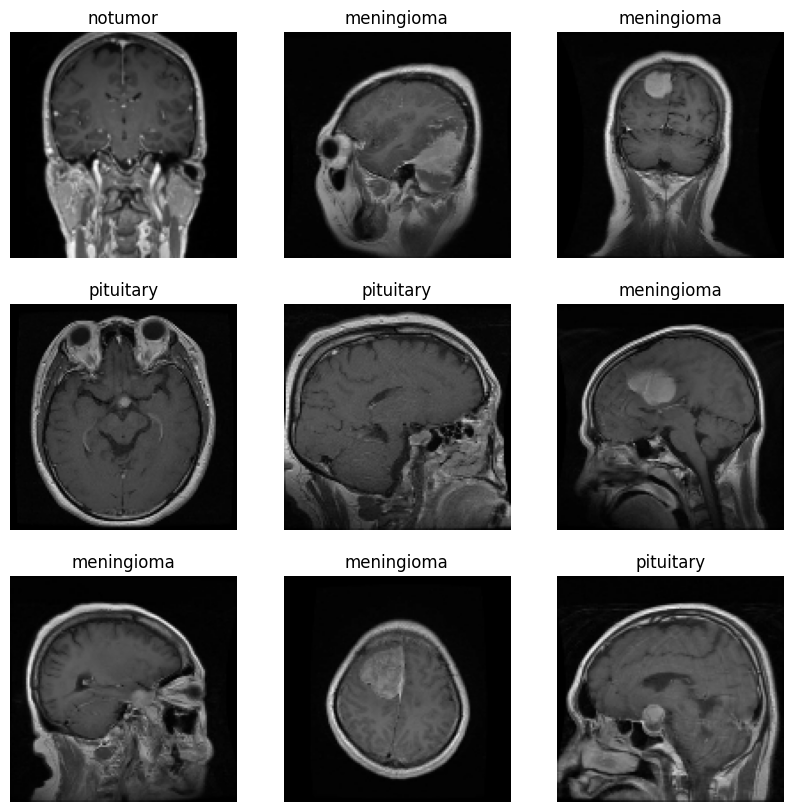

In [9]:
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [10]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation='softmax')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,915,470 (37.82 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,610,314 (25.22 MB)

In [13]:
history = model.fit(
    train_data,
    epochs=15
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 537ms/step - accuracy: 0.3988 - loss: 1.2915
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 554ms/step - accuracy: 0.5813 - loss: 0.9426
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 533ms/step - accuracy: 0.7063 - loss: 0.7592
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 535ms/step - accuracy: 0.7337 - loss: 0.6789
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 546ms/step - accuracy: 0.7925 - loss: 0.5483
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 540ms/step - accuracy: 0.8200 - loss: 0.4576
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 547ms/step - accuracy: 0.8438 - loss: 0.3986
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 545ms/step - accuracy: 0.8612 - loss: 0.3250
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 546ms/step - accuracy: 0.8712 - loss: 0.3306
Epoch 10/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 541ms/step - accuracy: 0.9050 - loss: 0.2499
Epoch 11/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 538ms/step - accuracy: 0.9062 - loss: 0.2267
Epoch 12/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 41

In [15]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy * 100, "%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.7750 - loss: 1.2414
Test Accuracy: 77.49999761581421 %


In [16]:
model.save("/content/brain_tumor_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [17]:
image_path = "/content/Dataset/Testing/meningioma/Te-aug-me_45.jpg"

img = tf.keras.utils.load_img(
    image_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# Prediction
prediction = model.predict(img_array, verbose=0)

# Print probability for all 4 classes
print("Prediction Probabilities:")
print("----------------------------")

for class_name, probability in zip(class_names, prediction[0]):
    print(f"{class_name}: {probability * 100:.2f}%")

# Find highest probability
highest_index = np.argmax(prediction[0])
predicted_class = class_names[highest_index]
confidence = prediction[0][highest_index] * 100

print("\n============================")
print("FINAL RESULT")
print("============================")
print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Prediction Probabilities:
----------------------------
glioma: 2.24%
meningioma: 97.73%
notumor: 0.03%
pituitary: 0.00%

FINAL RESULT
Predicted Class: meningioma
Confidence: 97.73%
